In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
pip install patchify

In [ ]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import cv2
from PIL import Image
from patchify import patchify
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import random

In [ ]:
minmaxscalar = MinMaxScaler()

In [ ]:
ls -lah

In [ ]:
dataset_root_folder = '/content/drive/MyDrive/major/'

In [ ]:
dataset_name = 'Folder'

In [ ]:
for path, subdirs, files in os.walk(os.path.join(dataset_root_folder, dataset_name)):
  dir_name = path.split(os.path.sep)[-1]
  #print(dir_name)
  if dir_name == 'images': #masks
    images = os.listdir(path)
    #print(path)
    #print(images)
    for i, image_name in enumerate(images):
      if(image_name.endswith('.jpg')): #.png
        #print(image_name)

        a = True

In [ ]:
image_patch_size = 256

In [ ]:
image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/images/image_01.jpg',1)

In [ ]:
image.shape

In [ ]:
image_patches = patchify(image, (image_patch_size, image_patch_size, 3), step = image_patch_size)

In [ ]:
print(image_patches.shape)

In [ ]:
image_x = image_patches[0,0,:,:]

#MinMaxScalar
image_y = minmaxscalar.fit_transform(image_x.reshape(-1, image_x.shape[-1])).reshape(image_x.shape)

In [ ]:
image_y[0].shape

In [ ]:


print(type(image))

In [ ]:
type(Image.fromarray(image))

In [ ]:
image.shape

In [ ]:
(image.shape[0]//image_patch_size)*image_patch_size
(image.shape[1]//image_patch_size)*image_patch_size

In [ ]:
image_dataset = []
mask_dataset = []

for image_type in ['images' , 'masks']:
  if image_type == 'images':
    image_extension = 'jpg'
  elif image_type == 'masks':
     image_extension = 'png'
  for image_id in range(1,9):
      image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/{image_type}/image_0{image_id}.{image_extension}',1)
      if image is not None:
        if image_type == 'masks':
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #print(image.shape)
        size_x = (image.shape[1]//image_patch_size)*image_patch_size
        size_y = (image.shape[0]//image_patch_size)*image_patch_size
        #print("{} --- {} - {}".format(image.shape, size_x, size_y))
        image = Image.fromarray(image)
        image = image.crop((0,0, size_x, size_y))
        #print("({},  {})".format(image.size[0],image.size[1]))
        image = np.array(image)
        patched_images = patchify(image, (image_patch_size, image_patch_size, 3), step=image_patch_size)
        #print(len(patched_images))
        for i in range(patched_images.shape[0]):
          for j in range(patched_images.shape[1]):
            if image_type == 'images':
              individual_patched_image = patched_images[i,j,:,:]
              #print(individual_patched_image.shape)
              individual_patched_image = minmaxscalar.fit_transform(individual_patched_image.reshape(-1, individual_patched_image.shape[-1])).reshape(individual_patched_image.shape)
              individual_patched_image = individual_patched_image[0]
              #print(individual_patched_image.shape)
              image_dataset.append(individual_patched_image)
            elif image_type == 'masks':
              individual_patched_mask = patched_images[i,j,:,:]
              individual_patched_mask = individual_patched_mask[0]
              mask_dataset.append(individual_patched_mask)

In [ ]:
print(len(image_dataset))
print(len(mask_dataset))

In [ ]:
image_dataset = np.array(image_dataset)
mask_dataset = np.array(mask_dataset)

In [ ]:
print(len(image_dataset))
print(len(mask_dataset))

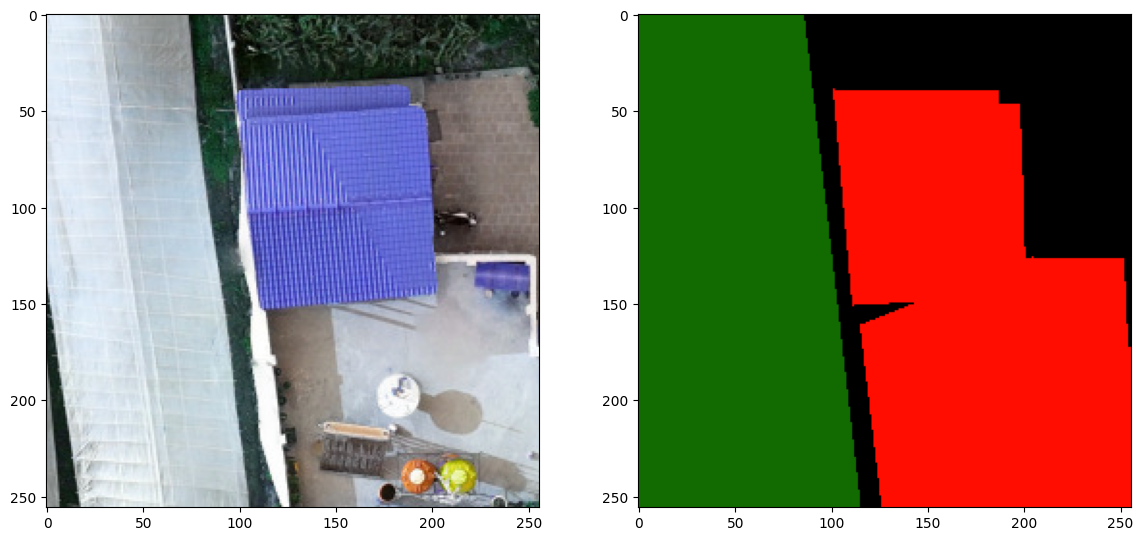

In [ ]:
random_image_id = random.randint(0, len(image_dataset)-1)

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.imshow(image_dataset[random_image_id])
plt.subplot(1,2,2)
plt.imshow(mask_dataset[random_image_id])


In [ ]:
class_building = '#FF0D00'
class_building = class_building.lstrip('#')
class_building = np.array(tuple(int(class_building[i:i+2], 16) for i in (0, 2, 4)))
print(class_building)

class_land = '#FFA200'
class_land = class_land.lstrip('#')
class_land = np.array(tuple(int(class_land[i:i+2], 16) for i in (0, 2, 4)))
print(class_land)

class_road = '#A020F0'
class_road = class_road.lstrip('#')
class_road = np.array(tuple(int(class_road[i:i+2], 16) for i in (0, 2, 4)))
print(class_road)

class_vegetation = '#126B00'
class_vegetation = class_vegetation.lstrip('#')
class_vegetation = np.array(tuple(int(class_vegetation[i:i+2], 16) for i in (0, 2, 4)))
print(class_vegetation)

class_water = '#006EFF'
class_water = class_water.lstrip('#')
class_water = np.array(tuple(int(class_water[i:i+2], 16) for i in (0, 2, 4)))
print(class_water)


In [ ]:
print(mask_dataset.shape)

In [ ]:
individual_patched_mask.shape

In [ ]:
label = individual_patched_mask

In [ ]:
def rgb_to_label(label):
  label_segment = np.zeros(label.shape, dtype=np.uint8)
  label_segment[np.all(label == class_land, axis=-1)] = 0
  label_segment[np.all(label == class_building, axis=-1)] = 1
  label_segment[np.all(label == class_road, axis=-1)] = 2
  label_segment[np.all(label == class_vegetation, axis=-1)] = 3
  label_segment[np.all(label == class_water, axis=-1)] = 4
  #print(label_segment)
  label_segment = label_segment[:,:,0]
  #print(label_segment)
  return label_segment

In [ ]:
labels = []
for i in range(mask_dataset.shape[0]):
  label = rgb_to_label(mask_dataset[i])
  labels.append(label)

In [ ]:
len(labels)

In [ ]:
labels = np.array(labels)

In [ ]:
labels[1]

In [ ]:
labels = np.expand_dims(labels, axis=3)

In [ ]:
labels[0]

In [ ]:
np.unique(labels)

In [ ]:
print("Total unique values based on masks: ",format(np.unique(labels)))

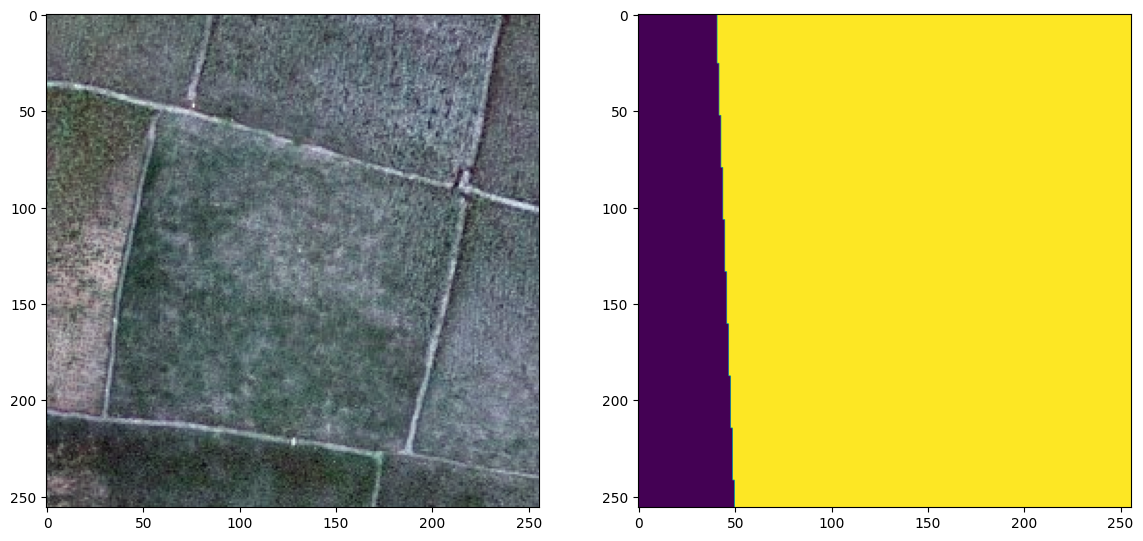

In [ ]:
random_image_id = random.randint(0, len(image_dataset)-1)

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.imshow(image_dataset[random_image_id])
plt.subplot(1,2,2)
#plt.imshow(mask_dataset[random_image_id])
plt.imshow(mask_dataset[random_image_id])
plt.imshow(labels[random_image_id][:,:,0])

In [ ]:
labels[0][:,:,0]

In [ ]:
total_classes = len(np.unique(labels))

In [ ]:
total_classes

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
labels_categorical_dataset = to_categorical(labels, num_classes = total_classes)

In [ ]:
labels_categorical_dataset.shape

In [ ]:
master_training_dataset = image_dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(master_training_dataset, labels_categorical_dataset, test_size=0.15, random_state = 100)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
image_height = x_train.shape[1]
image_width = x_train.shape[2]
image_channels = x_train.shape[3]
total_classes = y_train.shape[3]

In [ ]:
print(image_height)
print(image_width)
print(image_channels)
print(total_classes)

In [ ]:
 pip install --upgrade tensorflow keras segmentation-models

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda


In [ ]:
from keras import backend as K

In [ ]:
import tensorflow.keras.backend as K
import segmentation_models as sm
import tensorflow as tf

In [ ]:
def jaccard_coef(y_true, y_pred):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)
    intersection = K.sum(y_true_flatten * y_pred_flatten)
    final_coef_value = (intersection + 1.0) / (K.sum(y_true_flatten) + K.sum(y_pred_flatten) - intersection + 0.1)
    return final_coef_value

In [ ]:
from ctypes import c_int8
def multi_unet_model(n_classes = 5, image_height = 256, image_width = 256, image_channels = 1):

  inputs = Input((image_height, image_width, image_channels))

  source_input = inputs

  c1 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(source_input)
  c1 = Dropout(0.2)(c1)
  c1 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c1)
  p1 = MaxPooling2D((2,2))(c1)

  c2 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p1)
  c2= Dropout(0.2)(c2)
  c2 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c2)
  p2 = MaxPooling2D((2,2))(c2)

  c3 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p2)
  c3= Dropout(0.2)(c3)
  c3 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c3)
  p3 = MaxPooling2D((2,2))(c3)

  c4 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p3)
  c4= Dropout(0.2)(c4)
  c4 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c4)
  p4 = MaxPooling2D((2,2))(c4)

  c5 = Conv2D(256, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p4)
  c5= Dropout(0.2)(c5)
  c5 = Conv2D(256, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c5)

  u6 = Conv2DTranspose(128, (2,2), strides = (2,2), padding='same')(c5)
  u6 = concatenate([u6, c4])

  c6 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u6)
  c6 = Dropout(0.2)(c6)
  c6 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c6)

  u7 = Conv2DTranspose(64, (2,2), strides = (2,2), padding='same')(c6)
  u7 = concatenate([u7, c3])

  c7 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u7)
  c7 = Dropout(0.2)(c7)
  c7 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c7)

  u8 = Conv2DTranspose(32, (2,2), strides = (2,2), padding='same')(c7)
  u8 = concatenate([u8, c2])

  c8 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u8)
  c8 = Dropout(0.2)(c8)
  c8 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c8)

  u9 = Conv2DTranspose(16, (2,2), strides = (2,2), padding='same')(c8)
  u9 = concatenate([u9, c1], axis=3)

  c9 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u9)
  c9 = Dropout(0.2)(c9)
  c9 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c9)

  outputs = Conv2D(n_classes, (1,1), activation = 'softmax')(c9)

  model = Model(inputs = [inputs], outputs = [outputs])

  return model




In [ ]:
def get_deep_learning_model():
  return multi_unet_model(n_classes = total_classes, image_height = image_height, image_width = image_width, image_channels = image_channels)

In [ ]:
model = get_deep_learning_model()

In [ ]:
weights = tf.constant([0.166, 0.166, 0.166, 0.166, 0.166])  # 5 classes

In [ ]:
import segmentation_models as sm

In [ ]:
dice_loss = sm.losses.DiceLoss(class_weights=weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)


In [ ]:
import tensorflow as tf

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
model.compile(optimizer = 'adam', loss = total_loss, metrics = ['accuracy', jaccard_coef])

In [ ]:
model.summary()

In [ ]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")


x_train shape: (2704, 256, 256, 3)
y_train shape: (2704, 256, 256, 5)
x_test shape: (478, 256, 256, 3)
y_test shape: (478, 256, 256, 5)


In [ ]:
model_history = model.fit(
    x_train, y_train,
    batch_size=16,
    verbose=1,
    epochs=2,
    validation_data=(x_test, y_test),
    shuffle=False
)

Epoch 1/2
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5514 - jaccard_coef: 0.2349 - loss: 0.9928

/usr/local/lib/python3.10/dist-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


169/169 ━━━━━━━━━━━━━━━━━━━━ 1716s 10s/step - accuracy: 0.5515 - jaccard_coef: 0.2350 - loss: 0.9928 - val_accuracy: 0.6270 - val_jaccard_coef: 0.3253 - val_loss: 0.9769
Epoch 2/2
169/169 ━━━━━━━━━━━━━━━━━━━━ 1693s 10s/step - accuracy: 0.5964 - jaccard_coef: 0.3128 - loss: 0.9751 - val_accuracy: 0.6399 - val_jaccard_coef: 0.3387 - val_loss: 0.9696


In [ ]:
history_a=model_history

In [ ]:
history_a.history

{'accuracy': [0.5630655288696289, 0.6044231653213501],
 'jaccard_coef': [0.2625930607318878, 0.3222214877605438],
 'loss': [0.9860538244247437, 0.9735744595527649],
 'val_accuracy': [0.6269875764846802, 0.6398978233337402],
 'val_jaccard_coef': [0.3252604305744171, 0.33867841958999634],
 'val_loss': [0.9768795967102051, 0.9695693254470825]}

In [ ]:
import keras
from IPython.display import clear_output

%matplotlib inline

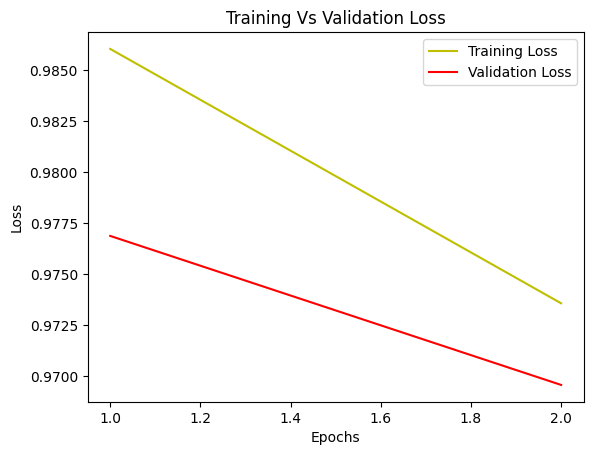

In [ ]:
loss = history_a.history['loss']
val_loss = history_a.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label="Training Loss")
plt.plot(epochs, val_loss, 'r', label="Validation Loss")
plt.title("Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

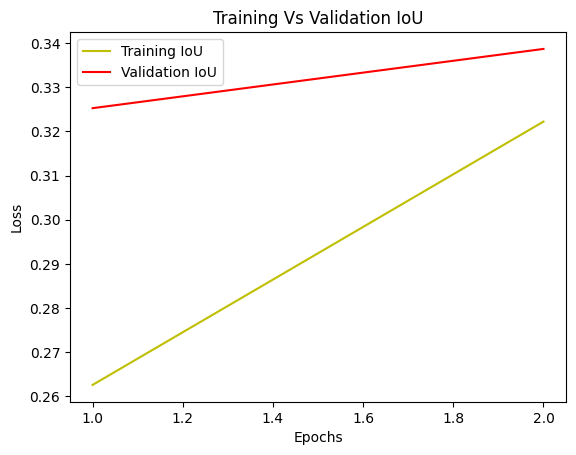

In [ ]:
jaccard_coef = history_a.history['jaccard_coef']
val_jaccard_coef = history_a.history['val_jaccard_coef']

epochs = range(1, len(jaccard_coef) + 1)
plt.plot(epochs, jaccard_coef, 'y', label="Training IoU")
plt.plot(epochs, val_jaccard_coef, 'r', label="Validation IoU")
plt.title("Training Vs Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model_history.params


{'verbose': 1, 'epochs': 2, 'steps': 169}

In [ ]:
y_pred = model.predict(x_test)

/usr/local/lib/python3.10/dist-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 256, 256, 3))
  warnings.warn(msg)


14/15 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

/usr/local/lib/python3.10/dist-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step


In [ ]:
len(y_pred)

478

In [ ]:

y_pred

array([[[[2.06902638e-01, 3.98640007e-01, 2.19622731e-01,
          1.41540706e-01, 3.32939290e-02],
         [2.04976067e-01, 5.32197118e-01, 1.79944262e-01,
          7.52564296e-02, 7.62619637e-03],
         [1.67042419e-01, 5.66394091e-01, 1.77769646e-01,
          8.21592733e-02, 6.63461117e-03],
         ...,
         [5.07776380e-01, 5.75680472e-02, 3.88843939e-02,
          3.71095091e-01, 2.46760957e-02],
         [5.11391521e-01, 7.19444230e-02, 4.80056703e-02,
          3.37386221e-01, 3.12721208e-02],
         [4.15711790e-01, 1.38145849e-01, 8.88417363e-02,
          2.91471809e-01, 6.58287406e-02]],

        [[1.89152494e-01, 5.99560082e-01, 1.51828423e-01,
          5.59511222e-02, 3.50796524e-03],
         [1.17094904e-01, 7.77520359e-01, 7.76411444e-02,
          2.74106134e-02, 3.32911935e-04],
         [1.00775562e-01, 8.17168057e-01, 5.83361872e-02,
          2.36156974e-02, 1.04426908e-04],
         ...,
         [4.50960040e-01, 1.81947425e-02, 1.07893953e-02,
   

In [ ]:

y_pred_argmax = np.argmax(y_pred, axis=3)

In [ ]:
len(y_pred_argmax)

478

In [ ]:

y_pred_argmax

array([[[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 3, 0, 0],
        [1, 1, 1, ..., 3, 3, 0],
        ...,
        [0, 0, 0, ..., 3, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [3, 3, 3, ..., 0, 0, 0],
        [3, 3, 3, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 3, 3, 0],
        [0, 0, 0, ..., 3, 0, 0],
        [0, 0, 0, ..., 3, 3, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 1, 1, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
y_test_argmax = np.argmax(y_test, axis=3)

In [ ]:

y_test_argmax

array([[[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       ...,

       [[3, 3, 3, ..., 1, 1, 1],
        [3, 3, 3, ..., 1, 1, 1],
        [3, 3, 3, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 3, 3, 3],
        [1, 1, 1, ..., 3, 3, 3],
        [1, 1, 1, ..., 3, 3, 3]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
import random

In [ ]:

test_image_number = random.randint(0, len(x_test))

test_image = x_test[test_image_number]
ground_truth_image = y_test_argmax[test_image_number]

test_image_input = np.expand_dims(test_image, 0)

prediction = model.predict(test_image_input)
predicted_image = np.argmax(prediction, axis=3)
predicted_image = predicted_image[0,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


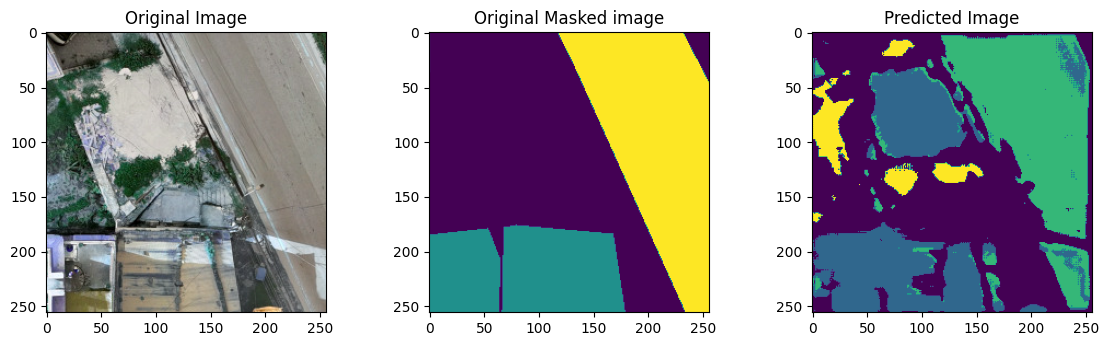

In [ ]:

plt.figure(figsize=(14,8))
plt.subplot(231)
plt.title("Original Image")
plt.imshow(test_image)
plt.subplot(232)
plt.title("Original Masked image")
plt.imshow(ground_truth_image)
plt.subplot(233)
plt.title("Predicted Image")
plt.imshow(predicted_image)
